# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

from os import path

from torch.utils.data import TensorDataset

from utils.plot import plot_digit_histograms

from scipy.ndimage import center_of_mass, shift

from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
# Setting torch seed
random_seed = 42
torch.manual_seed(random_seed)

# Import fine tunning data

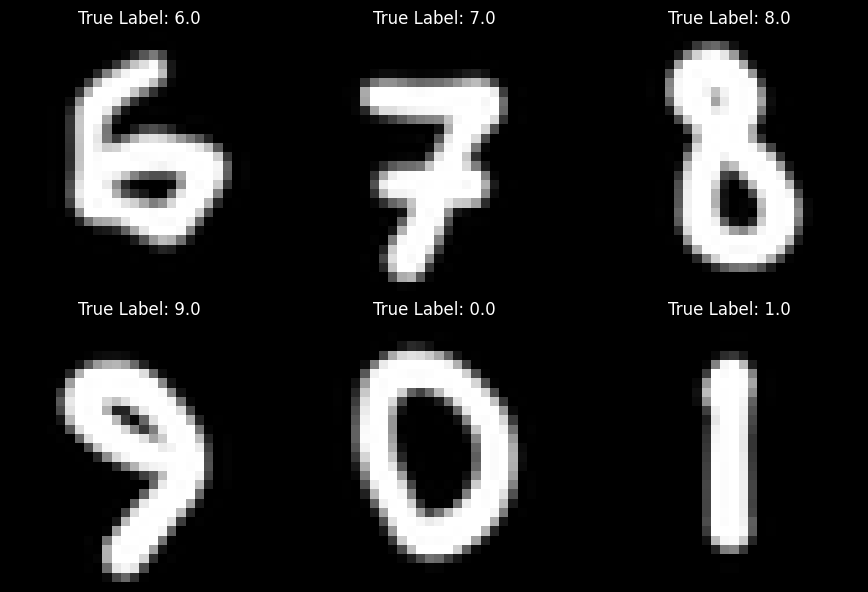

In [3]:
PATH = "fine-tuning-data-collector/fine_tune_data.csv"

line_data = np.genfromtxt(PATH, delimiter=',')

true_labels = np.array([d[0] for d in line_data], dtype=np.float32)
# Reshape, normalize in one line
data = np.array([(np.array(d[1:], dtype=np.float32) / 255.0).reshape((28, 28)) for d in line_data])

# Center image
centered_images = []
for img in data:
    if img.sum() < 1e-5:
        centered_images.append(img)
        continue

    c_y, c_x = center_of_mass(img)

    shift_x = 13.5 - c_x
    shift_y = 13.5 - c_y

    centered_image = shift(img, shift=(shift_y, shift_x), cval=0.0)
    centered_images.append(centered_image)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.imshow(centered_images[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"True Label: {true_labels[i]}")
    ax.axis('off')

plt.tight_layout()
# plt.savefig("six_images_subplots.png")

# Dara Preparation

## Splitting and shuffling data

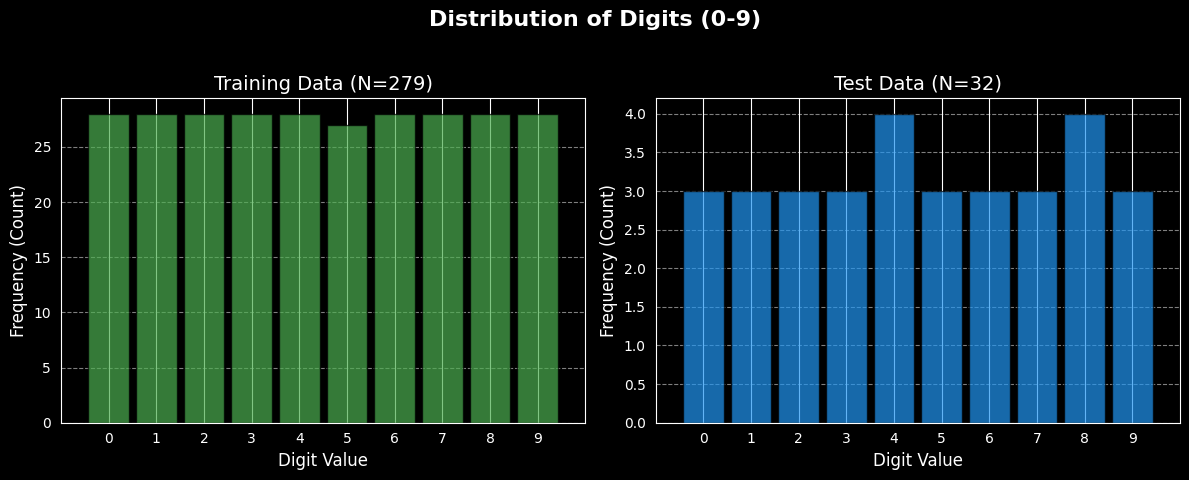

[2. 8. 0. 1. 9. 0. 3. 3. 5. 9. 6. 6. 0. 8. 1. 9. 4. 4. 2. 7. 7. 8. 2. 3.
 1. 5. 5. 8. 4. 6. 7. 4.]


In [4]:
np.random.seed(42)

# Use StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=random_seed)

N = len(data)

true_labels = np.array(true_labels)

train_idx, test_idx = next(sss.split(data, true_labels))

x_train, y_train = data[train_idx], true_labels[train_idx]
x_test, y_test = data[test_idx], true_labels[test_idx]

plot_digit_histograms(y_train, y_test)

print(y_test)

## Prepare data for torch

In [5]:
# Move Data to tensors
add_channel = lambda x: x.unsqueeze(1)

x_train_tensor, y_train_tensor = add_channel(torch.from_numpy(x_train)), torch.from_numpy(y_train).long()
x_test_tensor, y_test_tensor = add_channel(torch.from_numpy(x_test)), torch.from_numpy(y_test).long()

# Prepare Dataset
train_set = TensorDataset(x_train_tensor, y_train_tensor)
test_set = TensorDataset(x_test_tensor, y_test_tensor)

# Data loaders
train_batch_size = 16
test_batch_size = len(test_set)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=test_batch_size, shuffle=True)

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

example_data[0].shape

torch.Size([1, 28, 28])

## Define Transform (data augmentation)

In [6]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomRotation(degrees=5),
    torchvision.transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.10)),
    torchvision.transforms.ElasticTransform(alpha=10.0, sigma=5.0)
])

# Loading Model and reasuming training

Epoch 1 | Train loss 1.2950 | Validate loss 0.8064
Epoch 2 | Train loss 1.3484 | Validate loss 0.7893
Epoch 3 | Train loss 1.3778 | Validate loss 0.7689
Epoch 4 | Train loss 1.4960 | Validate loss 0.7537
Epoch 5 | Train loss 1.3381 | Validate loss 0.7393
Epoch 6 | Train loss 1.3336 | Validate loss 0.7248
Epoch 7 | Train loss 1.1815 | Validate loss 0.7136
Epoch 8 | Train loss 1.3574 | Validate loss 0.7031
Epoch 9 | Train loss 1.4469 | Validate loss 0.6946
Epoch 10 | Train loss 1.1958 | Validate loss 0.6876
Epoch 11 | Train loss 1.3482 | Validate loss 0.6785
Epoch 12 | Train loss 1.2927 | Validate loss 0.6679
Epoch 13 | Train loss 1.1226 | Validate loss 0.6579
Epoch 14 | Train loss 1.3858 | Validate loss 0.6475
Epoch 15 | Train loss 1.1441 | Validate loss 0.6420
Epoch 16 | Train loss 1.0450 | Validate loss 0.6384
Epoch 17 | Train loss 1.1158 | Validate loss 0.6335
Epoch 18 | Train loss 1.0549 | Validate loss 0.6297
Epoch 19 | Train loss 1.1855 | Validate loss 0.6232
Epoch 20 | Train loss

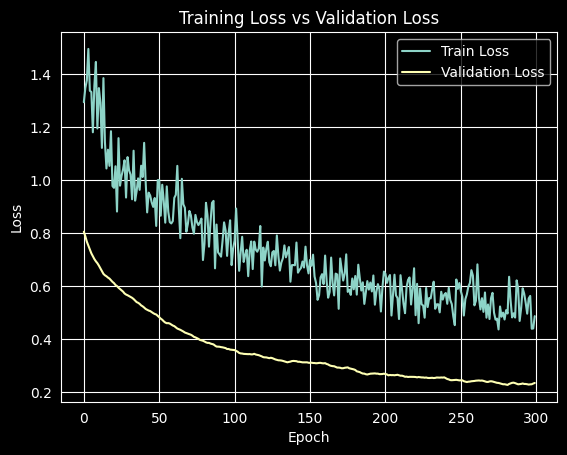

In [7]:
from Model import MyModel

# Hyperparameters
n_epochs = 300
learning_rate = 0.1e-3

# Use GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
PARAMS_PATH = path.join("trained_models", "model.pth")
model = MyModel().to(device)
model.load_state_dict(torch.load(PARAMS_PATH, map_location=device))

# Freeze convolutional layers
for param in model.conv1.parameters():
    param.requires_grad = False
for param in model.conv2.parameters():
    param.requires_grad = False

# Update only the unfrozen layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

criterion = nn.NLLLoss()

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        # Apply data augmentation
        data = train_transform(data)

        # Transfer data to GPU
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        epoch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    # Calculate average loss for the entire epoch
    avg_loss = sum(epoch_loss) / len(epoch_loss)
    train_losses.append(avg_loss)

    # Validate on the test set
    model.eval()
    epoch_val_loss = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            epoch_val_loss.append(loss.item())
    avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1} | Train loss {avg_loss:.4f} | Validate loss {avg_val_loss:.4f}")

# Training Loss vs Validation Loss (to prevent overfitting)
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Model Testing


In [8]:
# WE CANNOT USE DATA FROM TEST_LOADER BECAUSE OF DATA LEAKAGE RIGHT NOW, IF WE WANT TO TEST THE MODEL'S ACCURACY, WE NEED TO CREATE ADDITIONAL TEST AND VALIDATION SET (RIGHT NOW, DUE TO INSUFFICIENT DATA IN THE CSV FILE FOR FINE-TUNING, IT IS IMPOSSIBLE

# model.eval()
#
# # Disable gradient calculation
# with torch.no_grad():
#     for (data, target) in test_loader:
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         y_hat = output.data.max(1, keepdim=True)[1]
#         correct += y_hat.eq(target.data.view_as(y_hat)).sum()
#
# accuracy = correct / len(test_set)
#
# print(f"{accuracy=}")

# Saving a model


In [9]:
torch.save(model.state_dict(), "trained_models/model_fine_tuned.pth")